# Effect of Shear Deformation on a Stepped Shaft Under Distributed Loads: Euler–Bernoulli vs. Timoshenko

**Case:** `stepped_shafts / distributed_load / case_distributed_gear_parabolic`
**Study type:** model comparison (study, not validation)
**Status:** provisional

## Question

What is the contribution of shear deformation to the deflection of a
stepped shaft loaded only by distributed loads — gear mesh forces spread
uniformly over the face width and a parabolic user load — and how much do
the Cowper and Hutchinson shear correction factors differ?

## Method in brief

The same resolved system is solved with three beam models — Euler–Bernoulli
(EB) and Timoshenko with the Cowper and Hutchinson factors $\kappa$ — on the
**minimal mesh** (mandatory nodes only). Each result is compared with the
exact solution of its own beam theory (`references/beams/stepped_beam.py`), so that
discretisation error is not mistaken for a physical effect. Mesh
convergence of the Timoshenko element is treated in notebook 02.

In [1]:
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from validation._support.figures import shaft_studies as fg
from references.beams import stepped_beam as an
import construction as cd
from axisforge.core.loads import LoadPlane

fg.use_style()
pd.set_option("display.float_format", lambda v: f"{v:.4g}")

## 1. Case definition

All input data are taken from `construction.py`; nothing is redeclared
in this notebook.

In [2]:
segs = cd.segments()
system = cd.build_system()
SUPPORTS = (cd.BALL_POSITION_MM, cd.ROLLER_POSITION_MM)

pd.DataFrame(
    [(label, s.x_lo, s.x_hi, s.d, s.I, s.A) for (_, _, label), s in zip(cd.SECTIONS, segs)],
    columns=["Section", "x_lo / mm", "x_hi / mm", "d / mm", "I / mm⁴", "A / mm²"],
)

,Section,x_lo / mm,x_hi / mm,d / mm,I / mm⁴,A / mm²
0,bearing_seat_A,0,20,20,7854,314.2
1,body_left,20,85,28,3.017e+04,615.8
2,gear_seat,85,115,25,1.917e+04,490.9
3,body_right,115,180,28,3.017e+04,615.8
4,bearing_seat_B,180,200,20,7854,314.2


In [3]:
pd.DataFrame(
    [
        ("Material", "—", cd.MATERIAL_ID, "—"),
        ("Young's modulus", "E", cd.E_MPA, "MPa"),
        ("Poisson's ratio", "ν", cd.POISSON, "—"),
        ("Shoulder fillet radius", "r", cd.SHOULDER_FILLET_MM, "mm"),
        ("Locating bearing (6204)", "x_A", cd.BALL_POSITION_MM, "mm"),
        ("Non-locating bearing (NU204)", "x_B", cd.ROLLER_POSITION_MM, "mm"),
        ("Gear face width", "b", cd.GEAR_FACE_WIDTH_MM, "mm"),
        ("Transmitted power", "P", cd.POWER_W / 1e3, "kW"),
        ("Parabolic load, resultant", "F", cd.PARABOLIC_RESULTANT_N, "N"),
        ("Parabolic load, width", "w", cd.PARABOLIC_WIDTH_MM, "mm"),
        ("Parabolic load, peak intensity", "q₀", cd.PARABOLIC_PEAK_N_PER_MM, "N/mm"),
    ],
    columns=["Quantity", "Symbol", "Value", "Unit"],
)

,Quantity,Symbol,Value,Unit
0,Material,—,S355,—
1,Young's modulus,E,2.1e+05,MPa
2,Poisson's ratio,ν,0.3,—
3,Shoulder fillet radius,r,1,mm
4,Locating bearing (6204),x_A,10,mm
5,Non-locating bearing (NU204),x_B,190,mm
6,Gear face width,b,15,mm
7,Transmitted power,P,10.47,kW
8,"Parabolic load, resultant",F,2000,N
9,"Parabolic load, width",w,40,mm


Distributed loads acting on each shaft after the gear mesh has been
resolved, with their resultants in the two bending planes:

In [4]:
rows = []
for ss in system.shafts:
    for ld in ss.distributed_radial_loads:
        rows.append((ss.name, ld.label, ld.source, ld.x_lo, ld.x_hi, float(ld.magnitude),
                     float(ld.resultant_component(LoadPlane.XY)),
                     float(ld.resultant_component(LoadPlane.XZ))))
pd.DataFrame(rows, columns=["Shaft", "Load", "Source", "x_lo / mm", "x_hi / mm",
                            "|F| / N", "F_xy / N", "F_xz / N"])

,Shaft,Load,Source,x_lo / mm,x_hi / mm,|F| / N,F_xy / N,F_xz / N
0,shaft1,parabolic_user_load,user,40,80,2000,-3.674e-13,-2000
1,shaft1,g_driver:Fr,gear_mesh,92.5,107.5,1820,1820,0
2,shaft1,g_driver:Ft,gear_mesh,92.5,107.5,5000,3.062e-13,5000
3,shaft2,g_driven:Fr,gear_mesh,92.5,107.5,1820,-1820,2.229e-13
4,shaft2,g_driven:Ft,gear_mesh,92.5,107.5,5000,3.062e-13,5000
5,shaft2,parabolic_user_load,user,130,170,2000,-3.674e-13,-2000


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


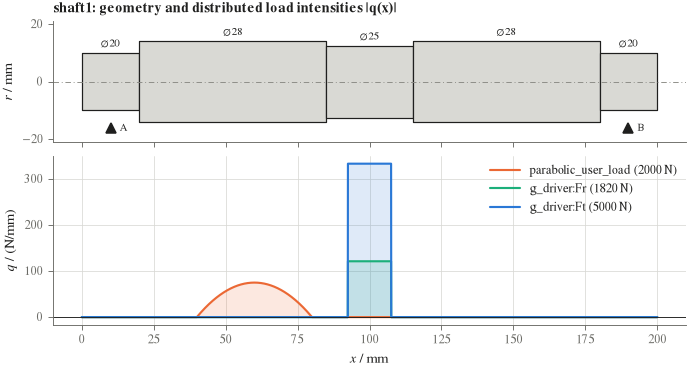

In [5]:
def layout_figure(shaft: str):
    ss = next(s for s in system.shafts if s.name == shaft)
    x = np.linspace(0.0, cd.SHAFT_LENGTH_MM, 4001)
    colours = {"parabolic_user_load": "#eb6834"}
    series = []
    for ld in ss.distributed_radial_loads:
        q = np.array([abs(ld.q(xi)) if ld.x_lo <= xi <= ld.x_hi else 0.0 for xi in x])
        series.append(fg.Series(label=f"{ld.label} ({abs(ld.magnitude):.0f} N)", x=x, y=q,
                                color=colours.get(ld.label, "#2a78d6" if ld.label.endswith("Ft") else "#1baf7a")))
    edges = [segs[0].x_lo] + [s.x_hi for s in segs]
    return fg.shaft_layout(edges, [s.d for s in segs], series,
                           title=f"{shaft}: geometry and distributed load intensities |q(x)|",
                           supports=SUPPORTS, support_names=("A", "B"))

fig_layout_1 = layout_figure("shaft1")

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


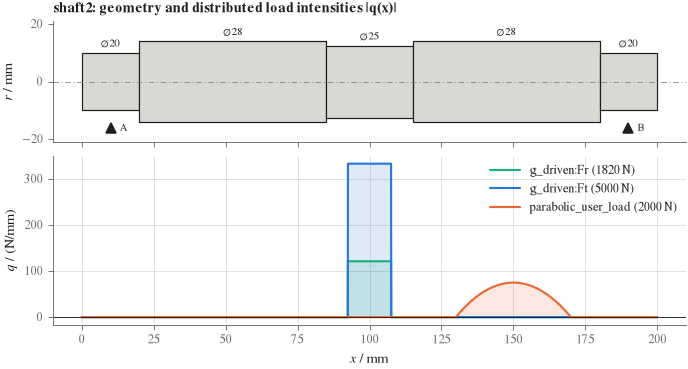

In [6]:
fig_layout_2 = layout_figure("shaft2")

## 2. Theoretical background

**Euler–Bernoulli.** Plane cross-sections remain perpendicular to the
neutral axis; on a stepped shaft the bending stiffness is piecewise
constant:

$$ \frac{d^2 v}{dx^2} = \frac{M(x)}{EI(x)}. $$

**Timoshenko.** The cross-section rotation $\theta$ is independent of the
slope; the shear strain, uniform over the section after the correction
factor $\kappa$, is

$$ \frac{d\theta}{dx} = \frac{M}{EI(x)}, \qquad
   \gamma = \frac{dv}{dx} - \theta = \frac{V}{\kappa G A(x)}, \qquad
   V = -\frac{dM}{dx}. $$

The shear contribution to the deflection is therefore
$v_s(x) = \int V/(\kappa G A)\,dx + C_1 x + C_2$. On a uniform shaft this
reduces to $-M/(\kappa GA)$; on a stepped shaft $\kappa G A$ changes at each
shoulder and the integral must be carried out section by section. In both
cases the shear contribution adds to the bending contribution.

**Shear correction factors, solid circular section:**

$$ \kappa_\text{Cowper} = \frac{6(1+\nu)}{7+6\nu} \quad\text{(Cowper, 1966)}, \qquad
   \kappa_\text{Hutchinson} = \frac{6(1+\nu)^2}{7+12\nu+4\nu^2} \quad\text{(Hutchinson, 2001)}. $$

**Static determinacy.** With two simple supports the reactions and $M(x)$
follow from equilibrium alone and are **identical for all three models**;
only the deflections and rotations change.

**Distributed loads in the FEM.** Loads are converted into consistent
nodal loads: forces and moments for the EB (Hermite) element, forces only
for the Timoshenko element, whose rotation is interpolated independently
of the deflection.

In [7]:
kappa = {name: f(cd.POISSON) for name, f in an.KAPPA.items()}

from axisforge.mesh.shaft.element_type.shear_factor import ShearFactor  # cross-check
sf = ShearFactor()
assert np.isclose(kappa["cowper"], sf.cowper_factor(cd.POISSON))
assert np.isclose(kappa["hutchinson"], sf.hutchinson_factor(cd.POISSON))

exact = {
    (ss.name, name): an.solve_shaft(ss, segs, None if st.shear_theory is None else kappa[st.shear_theory],
                                    cd.SHAFT_LENGTH_MM)
    for ss in system.shafts for name, st in cd.THEORIES.items()
}
xd = np.linspace(0.0, cd.SHAFT_LENGTH_MM, 4001)
pd.DataFrame(
    [(shaft, name, float(np.max(sol.v(xd))), float(xd[np.argmax(sol.v(xd))]))
     for (shaft, name), sol in exact.items()],
    columns=["Shaft", "Model", "v_max exact / mm", "x(v_max) / mm"],
)

,Shaft,Model,v_max exact / mm,x(v_max) / mm
0,shaft1,euler_bernoulli,0.09527,101.7
1,shaft1,timoshenko/cowper,0.09999,101.6
2,shaft1,timoshenko/hutchinson,0.09979,101.6
3,shaft2,euler_bernoulli,0.1005,98.5
4,shaft2,timoshenko/cowper,0.1054,98.55
5,shaft2,timoshenko/hutchinson,0.1052,98.55


## 3. Mesh

Only the mandatory nodes are used: shaft ends, section boundaries
(shoulders), bearing centres and extents, gear centre and face-width
limits, and the limits and centroids of the distributed loads.

In [8]:
results = {name: cd.solve(system, settings) for name, settings in cd.THEORIES.items()}
r0 = results["euler_bernoulli"]["shaft1"]
display(Markdown(f"Minimal mesh: **{len(r0.x_nodes)} nodes**, "
                 f"element length {np.min(np.diff(r0.x_nodes)):.1f}–{np.max(np.diff(r0.x_nodes)):.1f} mm."))

Minimal mesh: **18 nodes**, element length 3.0–65.0 mm.

## 4. Results

### 4.1 Static determinacy check

The reactions must coincide across models to round-off precision. The
bending moment is sampled differently by the two elements: the Hermite
element gives a linear $M$ within each element and the linear Timoshenko
element a constant one, so under distributed loads both deviate from the
exact, curved $M(x)$ on a coarse mesh.

In [9]:
rows = []
for name, res in results.items():
    for shaft, r in res.items():
        R_A, R_B = (b.Fr for b in r.bearing_nodes)
        sol = exact[(shaft, name)]
        rows.append((shaft, name, R_A, R_B,
                     float(np.hypot(sol.xy.R_A, sol.xz.R_A)), float(np.hypot(sol.xy.R_B, sol.xz.R_B)),
                     r.v_max, r.M_max, float(np.max(sol.M(xd)))))
summary = pd.DataFrame(rows, columns=["Shaft", "Model", "R_A FEM / N", "R_B FEM / N",
                                      "R_A exact / N", "R_B exact / N",
                                      "v_max FEM / mm", "M_max FEM / N·mm", "M_max exact / N·mm"])
summary

,Shaft,Model,R_A FEM / N,R_B FEM / N,R_A exact / N,R_B exact / N,v_max FEM / mm,M_max FEM / N·mm,M_max exact / N·mm
0,shaft1,euler_bernoulli,1394,2147,1394,2147,0.09521,1.849e+05,1.836e+05
1,shaft2,euler_bernoulli,2248,1311,2248,1311,0.1004,1.94e+05,1.926e+05
2,shaft1,timoshenko/cowper,1394,2147,1394,2147,0.09565,1.802e+05,1.836e+05
3,shaft2,timoshenko/cowper,2248,1311,2248,1311,0.1009,1.889e+05,1.926e+05
4,shaft1,timoshenko/hutchinson,1394,2147,1394,2147,0.09545,1.802e+05,1.836e+05
5,shaft2,timoshenko/hutchinson,2248,1311,2248,1311,0.1007,1.889e+05,1.926e+05


### 4.2 Deflection along the shaft

Upper panel: resultant deflection $v = \sqrt{v_{xy}^2 + v_{xz}^2}$ of the
three FEM models on the minimal mesh. Lower panel: difference relative to
the EB result, normalised by the maximum EB deflection.

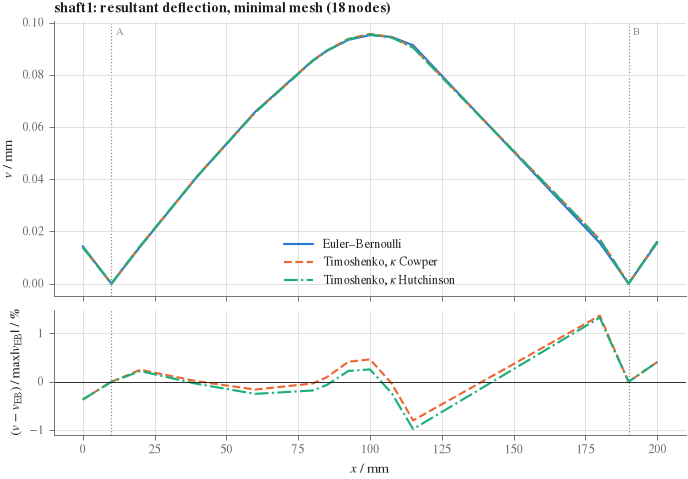

In [10]:
STYLE = {
    "euler_bernoulli": dict(label="Euler–Bernoulli", color="#2a78d6", linestyle="-"),
    "timoshenko/cowper": dict(label=r"Timoshenko, $\kappa$ Cowper", color="#eb6834", linestyle="--"),
    "timoshenko/hutchinson": dict(label=r"Timoshenko, $\kappa$ Hutchinson", color="#1baf7a", linestyle="-."),
}

def shear_figure(shaft: str):
    ref = results["euler_bernoulli"][shaft]
    scale = np.max(np.abs(ref.v))
    series, deltas = [], []
    for name, res in results.items():
        r = res[shaft]
        series.append(fg.Series(x=r.x, y=r.v, **STYLE[name]))
        if name != "euler_bernoulli":
            deltas.append(fg.Series(x=r.x, y=100 * (np.asarray(r.v) - np.asarray(ref.v)) / scale,
                                    **STYLE[name]))
    return fg.field_comparison(
        series, deltas,
        title=f"{shaft}: resultant deflection, minimal mesh ({len(ref.x_nodes)} nodes)",
        ylabel=r"$v$ / mm",
        delta_label=r"$(v - v_\mathrm{EB})\,/\,\max|v_\mathrm{EB}|$ / %",
        supports=SUPPORTS, support_names=("A", "B"),
    )

fig_shaft1 = shear_figure("shaft1")

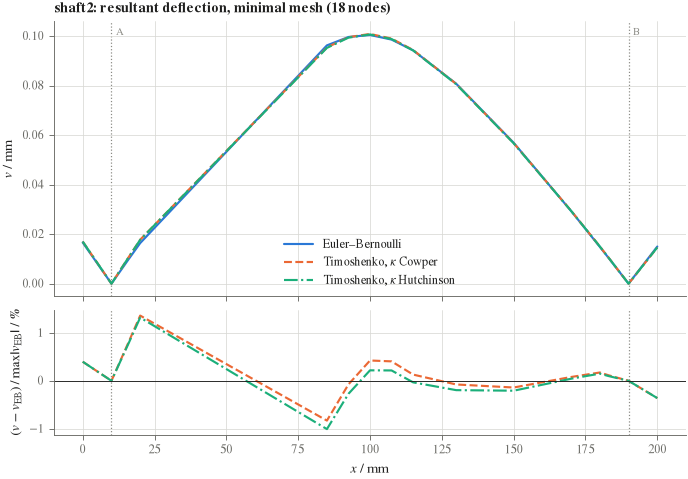

In [11]:
fig_shaft2 = shear_figure("shaft2")

### 4.3 Comparison with the analytical solution

Each FEM result is compared with the exact solution of the same beam
theory. The error is the maximum nodal deviation over both bending planes,
normalised by the maximum exact deflection.

In [12]:
def nodal_error(r, sol, field):
    x = np.asarray(r.x)
    num = max(float(np.max(np.abs(np.asarray(getattr(r, f"{field}_{p}")) - getattr(getattr(sol, p), field)(x))))
              for p in ("xy", "xz"))
    den = max(float(np.max(np.abs(getattr(getattr(sol, p), field)(xd)))) for p in ("xy", "xz"))
    return num / den

rows = []
for (shaft, name), sol in exact.items():
    r = results[name][shaft]
    rows.append((shaft, name, float(np.max(sol.v(xd))), r.v_max,
                 nodal_error(r, sol, "v"), nodal_error(r, sol, "M")))
check = pd.DataFrame(rows, columns=["Shaft", "Model", "v_max exact / mm", "v_max FEM / mm",
                                    "nodal error v", "nodal error M"])
check

,Shaft,Model,v_max exact / mm,v_max FEM / mm,nodal error v,nodal error M
0,shaft1,euler_bernoulli,0.09527,0.09521,1.612e-12,0.01204
1,shaft1,timoshenko/cowper,0.09999,0.09565,0.04879,0.3805
2,shaft1,timoshenko/hutchinson,0.09979,0.09545,0.04888,0.3805
3,shaft2,euler_bernoulli,0.1005,0.1004,2.194e-12,0.01137
4,shaft2,timoshenko/cowper,0.1054,0.1009,0.04859,0.3797
5,shaft2,timoshenko/hutchinson,0.1052,0.1007,0.04869,0.3797


## 5. Conclusions

In [13]:
ck = check.set_index(["Shaft", "Model"])
def inc(shaft, model):
    return 100 * (ck.loc[(shaft, model), "v_max exact / mm"]
                  / ck.loc[(shaft, "euler_bernoulli"), "v_max exact / mm"] - 1)
sm = summary.set_index(["Shaft", "Model"])
inc_fem = 100 * (sm.loc[("shaft1", "timoshenko/cowper"), "v_max FEM / mm"]
                 / sm.loc[("shaft1", "euler_bernoulli"), "v_max FEM / mm"] - 1)
display(Markdown(f"""
1. **Physical effect (exact solution):** shear deformation increases the maximum deflection
   by **{inc('shaft1', 'timoshenko/cowper'):.2f} %** / **{inc('shaft2', 'timoshenko/cowper'):.2f} %**
   (shaft1 / shaft2, Cowper) and **{inc('shaft1', 'timoshenko/hutchinson'):.2f} %** /
   **{inc('shaft2', 'timoshenko/hutchinson'):.2f} %** (Hutchinson). The choice between the two
   factors is immaterial for this shaft.
2. **Euler–Bernoulli on the minimal mesh** is exact at the nodes for the deflection
   (error {ck.loc[('shaft1', 'euler_bernoulli'), 'nodal error v']:.1e}), which verifies the
   consistent load vector of the distributed loads and the piecewise stiffness. Its bending
   moment is not exact under distributed loads (error
   {100 * ck.loc[('shaft1', 'euler_bernoulli'), 'nodal error M']:.1f} %), because the
   Hermite element represents $M$ as linear within each element.
3. **Timoshenko on the minimal mesh** deviates from its exact solution by
   **{100 * ck.loc[('shaft1', 'timoshenko/cowper'), 'nodal error v']:.1f} %** in deflection,
   of the same order as the shear effect itself: the FEM shows {inc_fem:+.1f} % relative to EB
   instead of {inc('shaft1', 'timoshenko/cowper'):+.2f} %. The minimal mesh is **not adequate
   for quantifying the shear effect** with the linear Timoshenko element; the converged mesh
   is determined in notebook 02.
4. The reactions coincide for all models and with the exact values, as required by static
   determinacy.
"""))


1. **Physical effect (exact solution):** shear deformation increases the maximum deflection
   by **4.95 %** / **4.90 %**
   (shaft1 / shaft2, Cowper) and **4.75 %** /
   **4.69 %** (Hutchinson). The choice between the two
   factors is immaterial for this shaft.
2. **Euler–Bernoulli on the minimal mesh** is exact at the nodes for the deflection
   (error 1.6e-12), which verifies the
   consistent load vector of the distributed loads and the piecewise stiffness. Its bending
   moment is not exact under distributed loads (error
   1.2 %), because the
   Hermite element represents $M$ as linear within each element.
3. **Timoshenko on the minimal mesh** deviates from its exact solution by
   **4.9 %** in deflection,
   of the same order as the shear effect itself: the FEM shows +0.5 % relative to EB
   instead of +4.95 %. The minimal mesh is **not adequate
   for quantifying the shear effect** with the linear Timoshenko element; the converged mesh
   is determined in notebook 02.
4. The reactions coincide for all models and with the exact values, as required by static
   determinacy.


## References

- Cowper, G. R. (1966). The shear coefficient in Timoshenko's beam theory.
  *J. Appl. Mech.* 33(2), 335–340.
- Hutchinson, J. R. (2001). Shear coefficients for Timoshenko beam theory.
  *J. Appl. Mech.* 68(1), 87–92.
- Timoshenko, S. P. & Gere, J. M. *Mechanics of Materials* — deflection of
  statically determinate beams by integration.